<a href="https://colab.research.google.com/github/chandBadal/AI_ML/blob/main/Tutorial_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Step-1

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


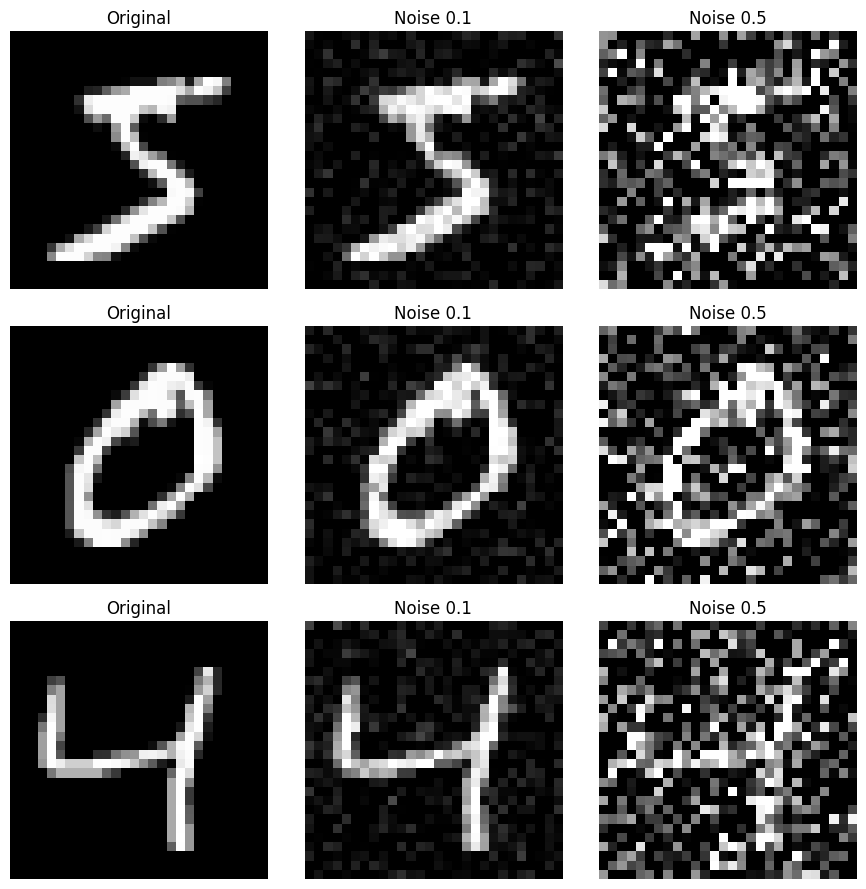

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# 1. Load dataset
(x_train, _), (x_test, _) = mnist.load_data()

# 2. Normalize (0–255 → 0–1)
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# 3. Reshape to (28, 28, 1)
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

# 4. Add Gaussian Noise
noise_factor_low = 0.1
noise_factor_high = 0.5

x_train_noisy_low = x_train + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_train_noisy_high = x_train + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)

# 5. Clip values (0–1)
x_train_noisy_low = np.clip(x_train_noisy_low, 0., 1.)
x_train_noisy_high = np.clip(x_train_noisy_high, 0., 1.)

# 6. Visualization
n = 3
plt.figure(figsize=(9, 9))

for i in range(n):
    # Original
    ax = plt.subplot(n, 3, i * 3 + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Low Noise
    ax = plt.subplot(n, 3, i * 3 + 2)
    plt.imshow(x_train_noisy_low[i].reshape(28, 28), cmap='gray')
    plt.title("Noise 0.1")
    plt.axis('off')

    # High Noise
    ax = plt.subplot(n, 3, i * 3 + 3)
    plt.imshow(x_train_noisy_high[i].reshape(28, 28), cmap='gray')
    plt.title("Noise 0.5")
    plt.axis('off')

plt.tight_layout()
plt.show()

#Step-2 Encoder

In [ ]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [ ]:
def build_encoder(input_shape=(28, 28, 1)):
    input_img = Input(shape=input_shape, name="input")

    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2, 2), padding='same', name="encoded")(x)

    return input_img, encoded

#Decoder

In [ ]:
def build_decoder(encoded_input):
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded_input)
    x = UpSampling2D((2, 2))(x)

    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)

    decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="decoded")(x)

    return decoded

#Autoencoder

In [ ]:
def build_autoencoder():
    input_img, encoded_output = build_encoder()
    decoded_output = build_decoder(encoded_output)

    autoencoder = Model(inputs=input_img, outputs=decoded_output, name="autoencoder")

    autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')

    return autoencoder

#Compile the Model

In [ ]:
autoencoder = build_autoencoder()
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

# Step-3 Training the autoencoder

In [ ]:
# Build model
autoencoder = build_autoencoder()

# Prepare x_test_noisy_high
x_test_noisy_high = x_test + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)
x_test_noisy_high = np.clip(x_test_noisy_high, 0., 1.)

# Train model
history = autoencoder.fit(
    x_train_noisy_high, x_train,   # input = noisy, target = clean
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy_high, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 163s 342ms/step - loss: 0.1588 - val_loss: 0.1166
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 161s 343ms/step - loss: 0.1127 - val_loss: 0.1083
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 155s 331ms/step - loss: 0.1071 - val_loss: 0.1038
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 155s 331ms/step - loss: 0.1040 - val_loss: 0.1019
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 206s 339ms/step - loss: 0.1019 - val_loss: 0.0999
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 201s 337ms/step - loss: 0.1004 - val_loss: 0.0988
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 201s 336ms/step - loss: 0.0993 - val_loss: 0.0979
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 157s 335ms/step - loss: 0.0984 - val_loss: 0.0972
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 157s 334ms/step - loss: 0.0976 - val_loss: 0.0965
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 202s 335ms/step - loss: 0.0970 - val_loss: 0.0964


#Step-4 Evaluate the Autoencoder

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step


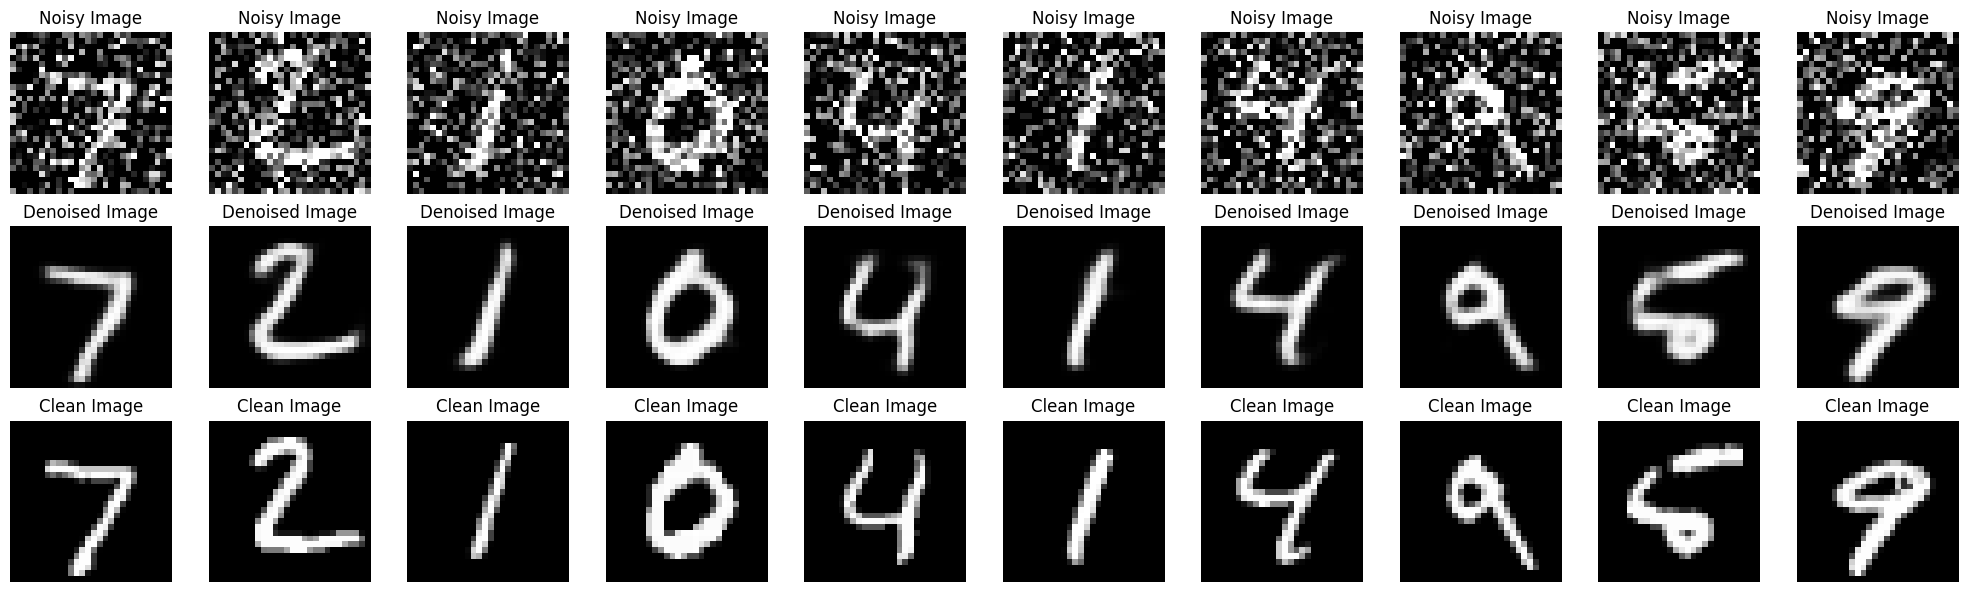

In [ ]:
# Predict denoised images (use correct variable name)
denoised_images = autoencoder.predict(x_test_noisy_high)

# Function to display images
import matplotlib.pyplot as plt

def plot_images(noisy_images, denoised_images, clean_images, n=10):
    plt.figure(figsize=(20, 6))

    for i in range(n):
        # Noisy images
        plt.subplot(3, n, i + 1)
        plt.imshow(noisy_images[i].reshape(28, 28), cmap='gray')
        plt.title("Noisy Image")
        plt.axis('off')

        # Denoised images
        plt.subplot(3, n, i + 1 + n)
        plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
        plt.title("Denoised Image")
        plt.axis('off')

        # Clean images
        plt.subplot(3, n, i + 1 + 2*n)
        plt.imshow(clean_images[i].reshape(28, 28), cmap='gray')
        plt.title("Clean Image")
        plt.axis('off')

    plt.tight_layout()
    plt.show()


# Display results
plot_images(x_test_noisy_high, denoised_images, x_test, n=10)

#Step 1: Load & Preprocess Devnagari Dataset

In [ ]:
import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split

# Dataset path
data_dir = "/content/drive/MyDrive/AI ML 2026/DevanagariHandwrittenDigitDataset"

images = []

# Loop main folders (Train/Test)
for main_folder in os.listdir(data_dir):
    main_path = os.path.join(data_dir, main_folder)

    if os.path.isdir(main_path):

        # Loop digit folders
        for digit_folder in os.listdir(main_path):
            digit_path = os.path.join(main_path, digit_folder)

            if os.path.isdir(digit_path):

                # Loop images
                for file in os.listdir(digit_path):
                    img_path = os.path.join(digit_path, file)

                    if file.endswith(('.png', '.jpg', '.jpeg')):

                        img = Image.open(img_path).convert('L')   # grayscale
                        img = img.resize((28, 28))                # resize
                        img = np.array(img)

                        images.append(img)

# Convert to numpy
images = np.array(images)

# Normalize
images = images.astype('float32') / 255.0

# Reshape
images = images.reshape(len(images), 28, 28, 1)

# Train-test split
x_train, x_test = train_test_split(images, test_size=0.2, random_state=42)

print("Train Shape:", x_train.shape)
print("Test Shape:", x_test.shape)

Train Shape: (16000, 28, 28, 1)
Test Shape: (4000, 28, 28, 1)


#Step 2: Add Noise

In [ ]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# Clip values
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

#Step 3: Build Deep Autoencoder (≥ 4 Layers)

In [ ]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

input_img = Input(shape=(28, 28, 1))

# -------- Encoder --------
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2), padding='same')(x)

# -------- Decoder --------
x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

# Model
autoencoder = Model(input_img, decoded)

autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

#Step 4: Train Model

In [ ]:
history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 37s 286ms/step - loss: 0.3106 - val_loss: 0.2173
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 30s 241ms/step - loss: 0.2084 - val_loss: 0.2071
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 40s 233ms/step - loss: 0.1995 - val_loss: 0.1972
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 234ms/step - loss: 0.1955 - val_loss: 0.1931
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 30s 239ms/step - loss: 0.1928 - val_loss: 0.1937
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 42s 246ms/step - loss: 0.1908 - val_loss: 0.1894
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 32s 259ms/step - loss: 0.1887 - val_loss: 0.1877
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 39s 246ms/step - loss: 0.1876 - val_loss: 0.1865
Epoch 9/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 40s 239ms/step - loss: 0.1865 - val_loss: 0.1855
Epoch 10/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 236ms/step - loss: 0.1855 - val_loss: 0.1850


#Plot Loss (Important for Report)

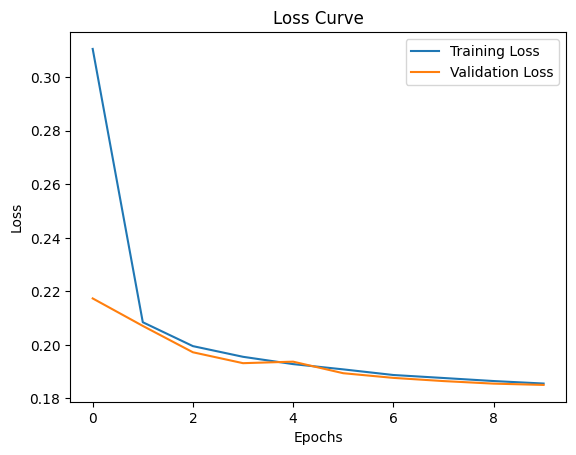

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

#Step 5: Evaluate & Visualize

125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step


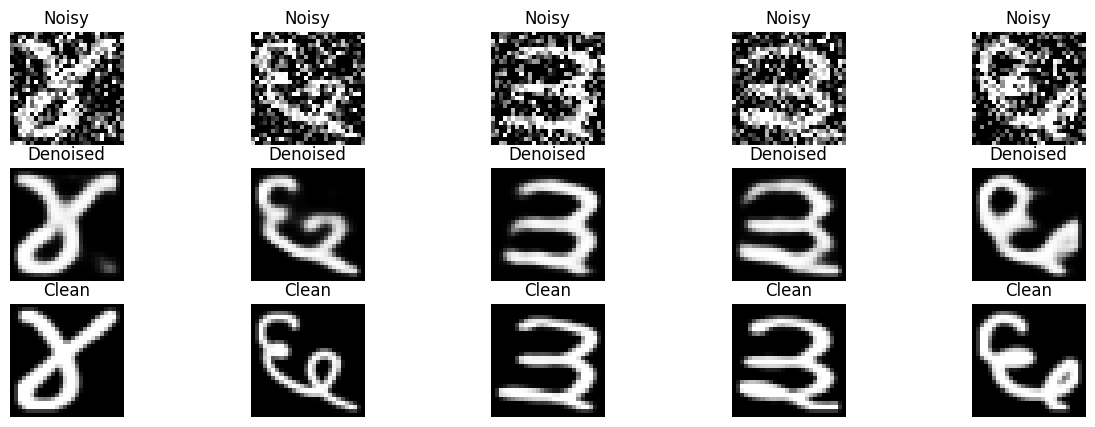

In [ ]:
# Predict
denoised_images = autoencoder.predict(x_test_noisy)

# Display images
def show_images(noisy, denoised, clean, n=5):
    plt.figure(figsize=(15,5))

    for i in range(n):
        # Noisy
        plt.subplot(3, n, i+1)
        plt.imshow(noisy[i].reshape(28,28), cmap='gray')
        plt.title("Noisy")
        plt.axis('off')

        # Denoised
        plt.subplot(3, n, i+1+n)
        plt.imshow(denoised[i].reshape(28,28), cmap='gray')
        plt.title("Denoised")
        plt.axis('off')

        # Clean
        plt.subplot(3, n, i+1+2*n)
        plt.imshow(clean[i].reshape(28,28), cmap='gray')
        plt.title("Clean")
        plt.axis('off')

    plt.show()

show_images(x_test_noisy, denoised_images, x_test)